<h3>Hannath T</h3>

<h2>FLIGHT PRICE PREDICTION</h2>

<h5>Problem Statement</h5>

Flight ticket prices are changing frequently making it hard to predict. 

Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable. That’s why we will try to use machine learning to solve this problem. This can help airlines by predicting what prices they can maintain. 


<h5>Goal</h5>

The goal is to create a model that can predict the flight ticket prices in advance based on Airline,Source,Destination,Stops,Duration etc..Making it helpful to customers plan travel accordingly,help travel companies suggest best prices and airline optimise pricing


***problem type is regression***

<h5>Attribute Information</h5>

1.	Airline: So this column will have all the types of airlines like Indigo, Jet Airways, Air India, and many more.
2.	Date_of_Journey: This column will let us know about the date on which the passenger’s journey will start.
3.	Source: This column holds the name of the place from where the passenger’s journey will start.
4.	Destination: This column holds the name of the place to where passengers wanted to travel.
5.	Route: Here we can know about what the route is through which passengers have opted to travel from his/her source to their destination.
6.	Arrival_Time: Arrival time is when the passenger will reach his/her destination.
7.	Duration: Duration is the whole period that a flight will take to complete its journey from source to destination.
8.	Total_Stops: This will let us know in how many places flights will stop there for the flight in the whole journey.
9.	Additional_Info: In this column, we will get information about food, kind of food, and other amenities.
10.	Price: Price of the flight for a complete journey including all the expenses before onboarding.


<h5>Tasks</h5>

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model which will help the customers to predict future flight prices and plan their journey accordingly.

Task 3:-Create a report stating the performance of multiple models on this data and suggest the best model for production.

Task 4:-Create a report which should include challenges you faced on data and what technique used with proper reason.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("Flight_Fare.xlsx")

In [3]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


<h3>Basic Checks</h3>

In [4]:
df.shape

(10683, 11)

- ***10683 rows and 11 columns present in dataset***

In [5]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


- ***all the features are object type***

In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

- ***2 null values present in the dataset***,\
small compared to the dataset size so dropping the route null value

In [9]:
df['Total_Stops'] = df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [11]:
df=df.dropna()

In [12]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(220)

In [14]:
duplicates = df[df.duplicated()]#seeing duplicates
duplicates.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
1685,Jet Airways,9/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 10 May,13h 30m,2 stops,No info,15129
1704,IndiGo,09/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,6860
1807,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,06:45,04:25 02 Jun,21h 40m,2 stops,In-flight meal not included,10919
1891,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,In-flight meal not included,10368
1971,Jet Airways,9/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,04:25 11 May,29h 20m,2 stops,No info,15129


In [15]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))#checking if they are exactly same ,keep=false takes duplicates and actual data
#keep=true takes duplicates while keeping one at the dataset

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
...,...,...,...,...,...,...,...,...,...,...,...
2870,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,4273
1535,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
3711,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
2634,Vistara,24/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,5403


- **The Duplicates are exact copies of all features ,so dropping duplicates**

In [16]:
df=df.drop_duplicates()#df.drop_duplicates(inplace=True)  

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.reset_index(drop=True, inplace=True)#reset index

Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 

In [19]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

- **No info and no info are same,so combining them**\
- **Very small count for many category ,combining them to single category -> other**

In [20]:
df['Additional_Info'] = df['Additional_Info'].str.lower()

In [21]:
df.Additional_Info.value_counts()

Additional_Info
no info                         8185
in-flight meal not included     1926
no check-in baggage included     318
1 long layover                    19
change airports                    7
business class                     4
1 short layover                    1
red-eye flight                     1
2 long layover                     1
Name: count, dtype: int64

In [22]:
df['Destination'].value_counts().sum

<bound method Series.sum of Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64>

- **Both new delhi and delhi is representing same location,converting New delhi to Delhi**\
- **Both New delhi and delhi has same airport for departure**

In [23]:
df['Destination'] = df['Destination'].replace({
    'New Delhi': 'Delhi'
})

In [24]:
df['Destination'].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        2179
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

<h3>Exploratory Data Analysis</h3>

<Axes: xlabel='Price', ylabel='Count'>

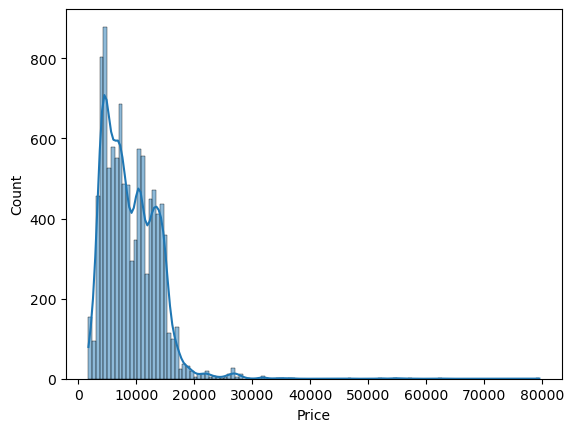

In [25]:
sns.histplot(df['Price'], kde=True)

- **the dataset is rightskewed as large amount of data is on low price category**

- **most flight price are in the range of 5000 to 10000 and Concentrated in lower range and Few extremely high prices**

- **Extreme values dominate the model,Model focuses too much on expensive flights,Predictions become unstable**

- **USing log transformation to reduce the skewness**

- **skew almost equal to 0 -> skew removed**

<Axes: ylabel='Price'>

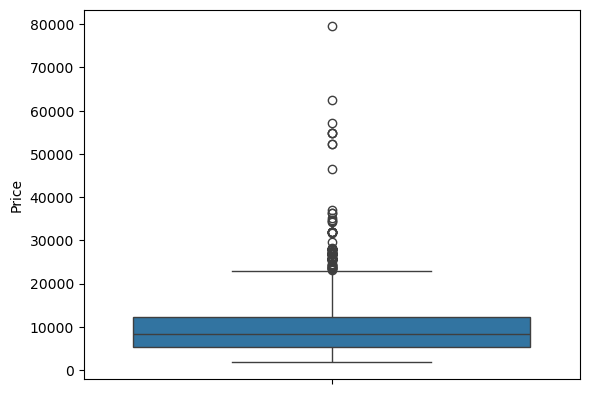

In [26]:
sns.boxplot(df['Price'])

- **Here Outliers are not data errors**

- **Outliers representing expensive flights and removing them could make the model bias towards cheaper flights(No expensive flights prediction)**

- **Dataset condain buisness and premium categories so high price is expected**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'IndiGo'),
  Text(1, 0, 'Air India'),
  Text(2, 0, 'Jet Airways'),
  Text(3, 0, 'SpiceJet'),
  Text(4, 0, 'Multiple carriers'),
  Text(5, 0, 'GoAir'),
  Text(6, 0, 'Vistara'),
  Text(7, 0, 'Air Asia'),
  Text(8, 0, 'Vistara Premium economy'),
  Text(9, 0, 'Jet Airways Business'),
  Text(10, 0, 'Multiple carriers Premium economy'),
  Text(11, 0, 'Trujet')])

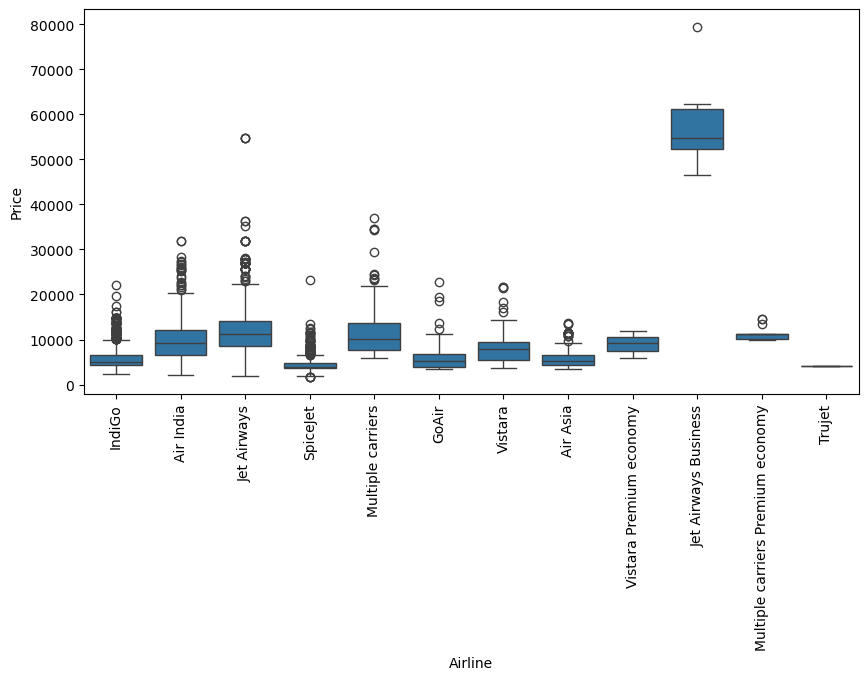

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)


- **Clearly premium and business flight is causing extreme values which is acceptable**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'IndiGo'),
  Text(1, 0, 'Air India'),
  Text(2, 0, 'Jet Airways'),
  Text(3, 0, 'SpiceJet'),
  Text(4, 0, 'Multiple carriers'),
  Text(5, 0, 'GoAir'),
  Text(6, 0, 'Vistara'),
  Text(7, 0, 'Air Asia'),
  Text(8, 0, 'Vistara Premium economy'),
  Text(9, 0, 'Jet Airways Business'),
  Text(10, 0, 'Multiple carriers Premium economy'),
  Text(11, 0, 'Trujet')])

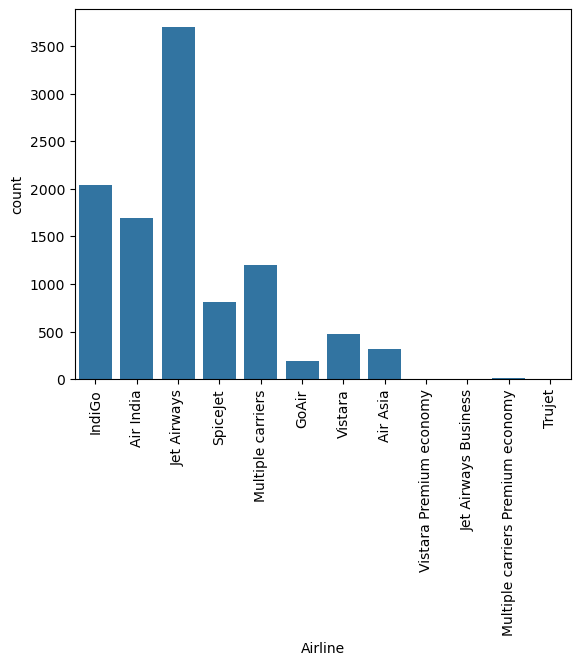

In [28]:
sns.countplot(x='Airline',data=(df))
plt.xticks(rotation=90)

- **the count of Multiple carriers Premium economy,Jet Airways Business,Vistara Premium economy,Trujet is very small ,so groupping them into single category**

In [29]:
df['Source'].value_counts().sum

<bound method Series.sum of Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64>

- **Chennai and Mumbai having least count while delhi peaked in counts**

Text(0, 0.5, 'Median Price')

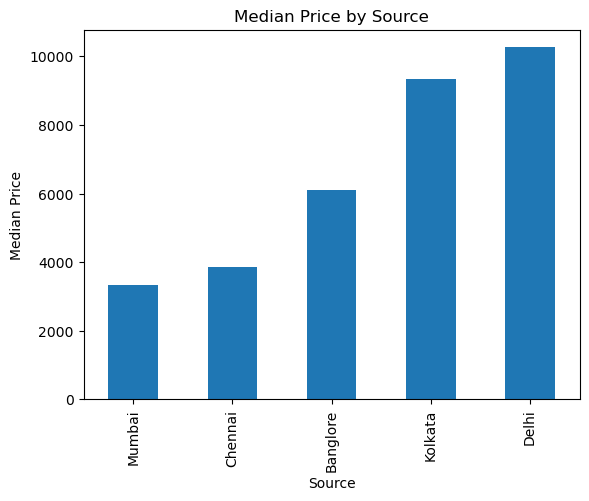

In [30]:
df.groupby('Source')['Price'].median().sort_values().plot(kind='bar')
plt.title("Median Price by Source")
plt.ylabel("Median Price")

- **Median because data is skewed and mean can be misleading**\
- **Delhi and kolkata has highest median price**\
- **Source can influence the price of flight**

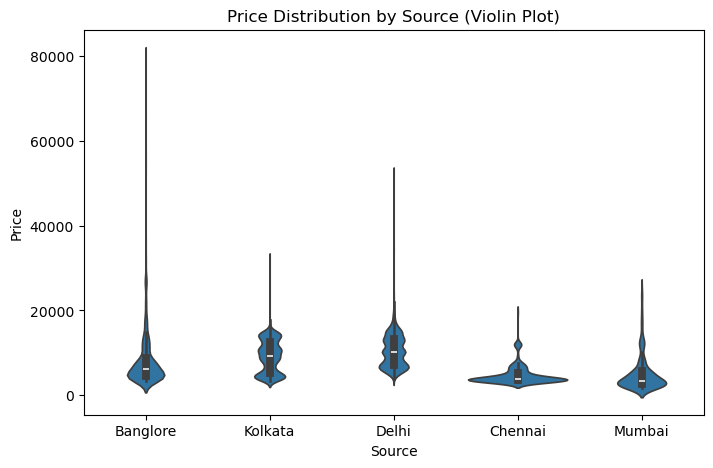

In [31]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Source', y='Price', data=df)
plt.title("Price Distribution by Source (Violin Plot)")
plt.show()

- **Chennai has more stable prices and low price concentration**\
- **Mumbai with second stable after chennai**\
- **Delhi and Kolkata is highly varieing**\
- **Banglore with moderate stablity and high price along with delhi**

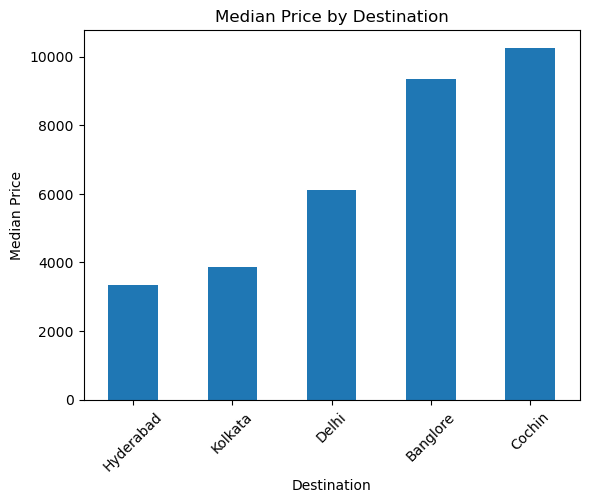

In [32]:
df.groupby('Destination')['Price'].median().sort_values().plot(kind='bar')
plt.title("Median Price by Destination")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

- **Cochin has highest median price**\
- **Banglore and Delhi with high median price after Cochin**

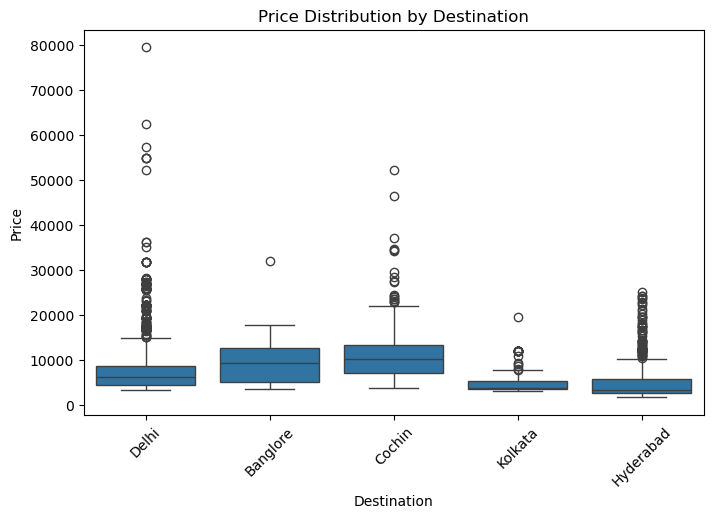

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Destination', y='Price', data=df)
plt.title("Price Distribution by Destination")
plt.xticks(rotation=45)
plt.show()

- **Flights to Cochin are generally more expensive and highly variable**\
- **Flights to Banglore are also showing high price ranges followed by flights to Delhi**\
- **large outliers can also represent premium tickets**

<Axes: xlabel='Total_Stops', ylabel='Price'>

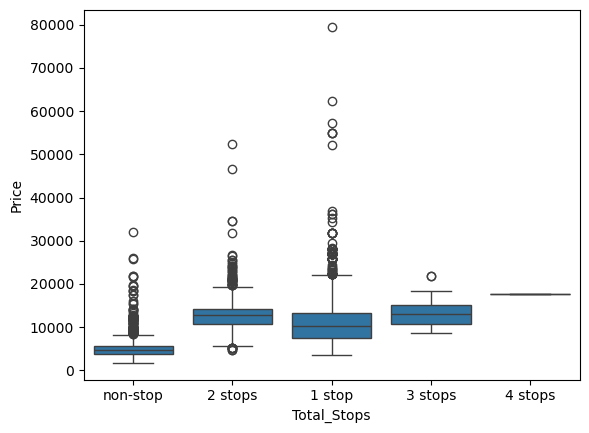

In [34]:
sns.boxplot(x='Total_Stops', y='Price', data=df)

- **This clearly indicates Total_Stops can be ordinal**

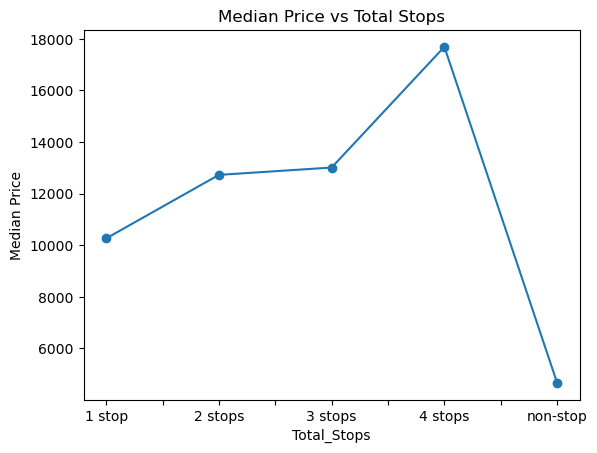

In [35]:
df.groupby('Total_Stops')['Price'].median().plot(marker='o')
plt.title("Median Price vs Total Stops")
plt.ylabel("Median Price")
plt.show()

- **The higher the no:of stop ,the more the price average and non-stop has low price average**\
- **No:of stops is highly influencing the Price of tickets**

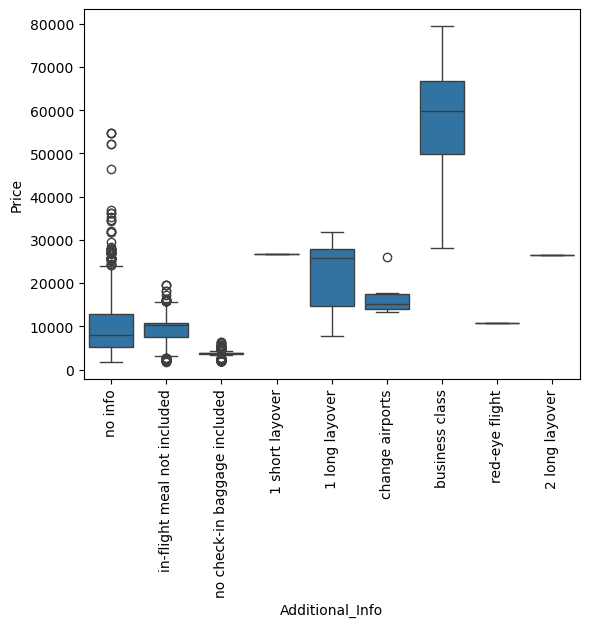

In [36]:
sns.boxplot(x='Additional_Info', y='Price', data=df)
plt.xticks(rotation=90)
plt.show()

- **Business class tickets has highest price range**\
- **1 long layover is showing high ranges ,1 long layover can means more routes(long duration)**\
- **No check in baggage included flights are with lowest price range and no big price variation**

**Heat map after Feature Engineering as there is no numerical features now**

<h3>Some importand Findings</h3>

- **Business class tickets has highest price range showing as outliers**\
- **No check in baggage included flights are with lowest price range and no big price variation**\
- **No:of stops is highly influencing the Price of tickets**\
- **Flights to Cochin are generally more expensive and highly variable**\
- **Flight from Chennai has more stable prices and low price concentration**\
- **Flight to Delhi and Kolkata is highly varieing**\
- **Delhi and kolkata has highest median price**\
- **Source can influence the price of flight**

<h3>Completed Task 1:-Prepare a complete data analysis report on the given data.</h3>

<h3>Feature engineering</h3>

In [37]:
df['Airline'].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

- **Multiple carriers Premium economy,Jet Airways Business,Vistara Premium economy,Trujet have very small counts,so rare category grouping them to single other category**

- **All of the rare category except Trujet are premium or buisness ,we could group them into premium/buisness,but other airlines names doesnt specified wheather its economy or buisness or premium,so choosing not to create premium/buisness.**

In [38]:
rare_airlines = df['Airline'].value_counts()[df['Airline'].value_counts() < 100].index
df['Airline'] = df['Airline'].replace(rare_airlines, 'Other')

In [39]:
df['Airline'].value_counts()

Airline
Jet Airways          3700
IndiGo               2043
Air India            1694
Multiple carriers    1196
SpiceJet              815
Vistara               478
Air Asia              319
GoAir                 194
Other                  23
Name: count, dtype: int64

In [40]:
df['Additional_Info'].value_counts()

Additional_Info
no info                         8185
in-flight meal not included     1926
no check-in baggage included     318
1 long layover                    19
change airports                    7
business class                     4
1 short layover                    1
red-eye flight                     1
2 long layover                     1
Name: count, dtype: int64

- **Very small count for many category ,combining them to single category -> other**\
- **but 1 long layover,change airports,business class showing impact on price so groping them as -> imporatant**

In [41]:
counts = df['Additional_Info'].value_counts()
rare = counts[counts < 20].index

df['Additional_Info'] = df['Additional_Info'].replace(rare, 'Other')

In [42]:
df['Additional_Info'].value_counts()

Additional_Info
no info                         8185
in-flight meal not included     1926
no check-in baggage included     318
Other                             33
Name: count, dtype: int64

In [43]:
df['Additional_Info'].value_counts()

Additional_Info
no info                         8185
in-flight meal not included     1926
no check-in baggage included     318
Other                             33
Name: count, dtype: int64

In [44]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

- **4 stops with 1 count ,combining with 3 stops and creating 3+ stops**

In [45]:
df['Total_Stops'] = df['Total_Stops'].replace({
    '3 stops': '3+ stops',
    '4 stops': '3+ stops'
})

In [46]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3+ stops      44
Name: count, dtype: int64

In [47]:
stops = {
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3+ stops': 3
}

df['Total_Stops'] = df['Total_Stops'].map(stops)

In [48]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')#converted to datetime in std format from(make it consider '%d/%m/%Y way(can be changed)) '%d/%m/%Y format

In [49]:
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Year'] = df['Date_of_Journey'].dt.year #exytacted day and month
df['Journey_Weekday'] = df['Date_of_Journey'].dt.weekday

In [50]:
df['Journey_Year'].value_counts()

Journey_Year
2019    10462
Name: count, dtype: int64

- **entire dataset have one single month 2019**

In [51]:
df[df['Route'].str.contains('→') == False]['Route']#no routes without ->

Series([], Name: Route, dtype: object)

In [52]:
df['Route_Length'] = df['Route'].str.count('→') + 1

In [53]:
df['Route_Length'].value_counts()

Route_Length
3    5625
2    3475
4    1318
5      43
6       1
Name: count, dtype: int64

In [54]:
df['Route_Length'] = df['Route_Length'].apply(lambda x: 5 if x >= 5 else x)

In [55]:
df['Route_Length'].value_counts()

Route_Length
3    5625
2    3475
4    1318
5      44
Name: count, dtype: int64

<Axes: xlabel='Route_Length', ylabel='Price'>

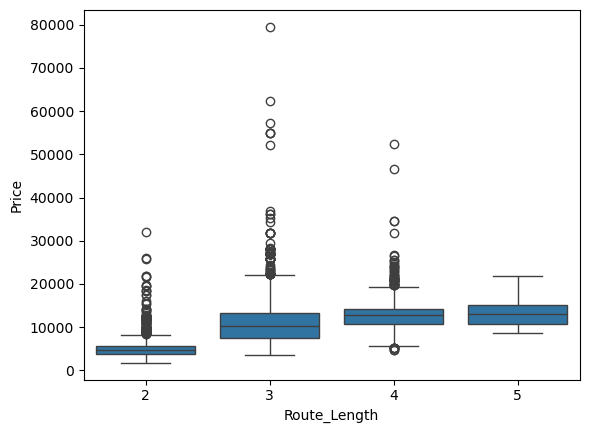

In [56]:
sns.boxplot(x='Route_Length', y='Price', data=df)

- **Longer the route larger the price**

In [57]:
dep_time = pd.to_datetime(df['Dep_Time'], format='%H:%M')
df['depa_hr'] = dep_time.dt.hour
df['depa_min'] = dep_time.dt.minute

In [58]:
df['Arrival_Time_Only'] = df['Arrival_Time'].str.split().str[0]#arrival has month and day along with time
df['Arrival_Time_Only'] = pd.to_datetime(df['Arrival_Time_Only'], format='%H:%M')

df['Arrival_Hour'] = df['Arrival_Time_Only'].dt.hour
df['Arrival_Minute'] = df['Arrival_Time_Only'].dt.minute

def time_category(hour):
    if 4 <= hour < 8:
        return " Early Morning"
    elif 8 <= hour <12:
        return " Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Dep_Time_Category"] = df["depa_hr"].apply(time_category)
df["Arrival_Time_Category"] = df["Arrival_Hour"].apply(time_category)

In [59]:
df['Dep_Total_Minutes'] = df['depa_hr'] * 60 + df['depa_min']
df['Arrival_Total_Minutes'] = df['Arrival_Hour'] * 60 + df['Arrival_Minute']

In [60]:
df['Duration'] = df['Duration'].str.replace('h','').str.replace('m','')
df['Duration_hours'] = df['Duration'].str.split().str[0].astype(int)
df['Duration_minutes'] = df['Duration'].str.split().str[1].fillna(0).astype(int)
df['Duration_total_mins'] = df['Duration_hours']*60 + df['Duration_minutes']

In [61]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Journey_Weekday', 'Route_Length', 'depa_hr',
       'depa_min', 'Arrival_Time_Only', 'Arrival_Hour', 'Arrival_Minute',
       'Dep_Total_Minutes', 'Arrival_Total_Minutes', 'Duration_hours',
       'Duration_minutes', 'Duration_total_mins'],
      dtype='object')

**Dropping unwanted and extracted columns**

In [62]:
columns_to_drop = [
    'Date_of_Journey',
    'Dep_Time',
    'Arrival_Time',
    'Arrival_Time_Only',
    'Duration',
    'Duration_hours',
    'Duration_minutes',
    'Journey_Year',
    'Route',
    'Arrival_Hour',
    'Arrival_Minute',
    'depa_hr',
    'depa_min',
    'Route_Length',
    
    
    
]

df.drop(columns=columns_to_drop, axis=1, inplace=True)

- **route length showing multicollinearity with total stops->dropping route length**\
- **route is combo of source stop and desti ,we already have**

In [63]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Journey_Day', 'Journey_Month', 'Journey_Weekday',
       'Dep_Total_Minutes', 'Arrival_Total_Minutes', 'Duration_total_mins'],
      dtype='object')

<h3>Heat map</</h3>

<Axes: >

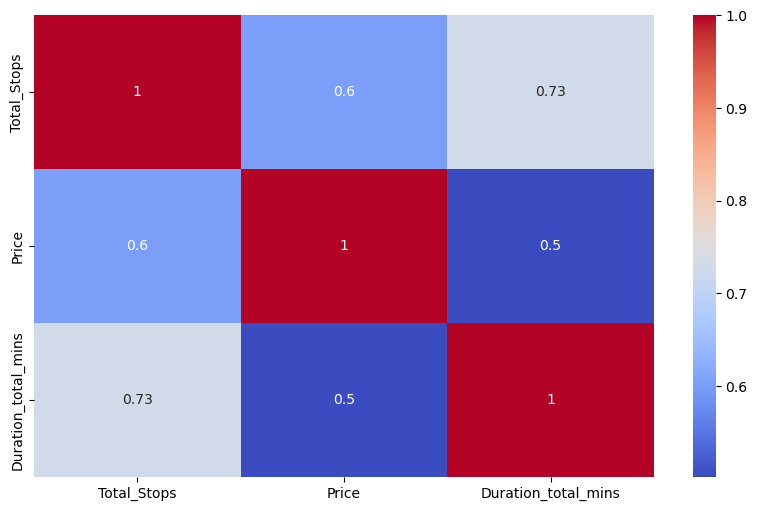

In [64]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

- **duration and total stop are related as number of stop increases duration increases**

In [65]:
#separating target
x = df.drop("Price", axis=1)
y = df["Price"]

In [66]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10457     4107
10458     4145
10459     7229
10460    12648
10461    11753
Name: Price, Length: 10462, dtype: int64

In [67]:
df['Price'].skew()#checks symmetry of target (skewed,no skewed)

np.float64(1.8574899082173875)

<h3>Train and Test split</h3>

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [69]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10457     4107
10458     4145
10459     7229
10460    12648
10461    11753
Name: Price, Length: 10462, dtype: int64

In [70]:
y_train.skew()

np.float64(1.9537777569867345)

- **Skew value > 1 (data is highly righ skewed)**

<h4>Log Transformation</h4>

In [71]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [72]:
y_train.skew()

np.float64(-0.23801011601524988)

- **skew value almost 0 ->skew solved**

<h3>Separating numerical and categorical features</h3>

In [73]:
categorical_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']

numerical_cols = ['Total_Stops', 'Journey_Day', 'Journey_Month','Journey_Weekday',
                  'Duration_total_mins', 'Dep_Total_Minutes',
                  'Arrival_Total_Minutes']

changes made : made category dep and arrival time cate
added to categoricals 
added scaler 'passthrough' instead added standade scaler

<h3>Preprocessing (One-Hot Encoding)</h3>

In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first',handle_unknown='ignore'), categorical_cols),
        ('num','passthrough', numerical_cols)
    ]
)

**Focusing on tree based model for the project so choosing to skip scaling**

Since flight pricing involves non-linear relationships and complex feature interactions, tree-based ensemble models were more suitable than linear regression, which assumes linearity.

handle_unknown='ignore'-> if encounder a new category

<h3>TRying Different Model</h3>

<h4> LinearRegression</h4>

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model', LinearRegression())])

In [76]:
# Overfitting check
print("Train R2:", lr_pipeline.score(x_train, y_train))
print("Test R2:", lr_pipeline.score(x_test, y_test))

Train R2: 0.7587171733409976
Test R2: 0.7517599759006139


In [77]:
y_pred_lr = lr_pipeline.predict(x_test)

if no log transform then -> y_test_eval = y_test else

In [78]:
y_pred_lr = np.expm1(y_pred_lr)#reverse log transform
y_test_eval = np.expm1(y_test)

clip predictions to avoid overflow
y_pred_lr = np.clip(y_pred_lr, -20, 20)

mask = np.isfinite(y_pred_lr) & np.isfinite(y_test_eval)

y_pred_lr = y_pred_lr[mask]
y_test_eval = y_test_eval[mask]

In [79]:
mae_lr = mean_absolute_error(y_test_eval, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_eval, y_pred_lr))
r2_lr = r2_score(y_test_eval, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

MAE: 1750.704319283874
RMSE: 2767.500225251049
R²: 0.6326639821005051


<h4> Decision Tree</h4>

In [80]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [81]:
# Overfitting check
print("Train R2:", dt_pipeline.score(x_train, y_train))
print("Test R2:", dt_pipeline.score(x_test, y_test))

Train R2: 0.9963879562251694
Test R2: 0.8968121962623463


***overfitting***

In [82]:
y_pred_dt = dt_pipeline.predict(x_test)

In [83]:
y_pred_dt = np.expm1(y_pred_dt)#reverse log transform
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [84]:
mae_dt = mean_absolute_error(y_test_eval, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_eval, y_pred_dt))
r2_dt = r2_score(y_test_eval, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

MAE: 767.6546949127309
RMSE: 1784.4043042468318
R²: 0.84728745733134


<h4>Random Forest</h4>

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [86]:
# Overfitting check
print("Train R2:", rf_pipeline.score(x_train, y_train))
print("Test R2:", rf_pipeline.score(x_test, y_test))

Train R2: 0.9884440288285011
Test R2: 0.9361244576426258


***Mild overfitting***

In [87]:
y_pred_rf = rf_pipeline.predict(x_test)

In [88]:
y_pred_rf = np.expm1(y_pred_rf)#reverse log transform
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [89]:
mae_rf = mean_absolute_error(y_test_eval, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_eval, y_pred_rf))
r2_rf = r2_score(y_test_eval, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 676.6223205732311
RMSE: 1500.0836453973534
R²: 0.8920757258847234


<h3>Gradient boost</h3>

In [90]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [91]:
# Overfitting check
print("Gradient Boosting")
print("Train R2:", gb_pipeline.score(x_train, y_train))
print("Test R2:", gb_pipeline.score(x_test, y_test))

Gradient Boosting
Train R2: 0.876810128386331
Test R2: 0.8658894513719156


In [92]:
y_pred_gb = gb_pipeline.predict(x_test)

In [93]:
y_pred_gb = np.expm1(y_pred_gb)
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [94]:
mae_gb = mean_absolute_error(y_test_eval, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_eval, y_pred_gb))
r2_gb = r2_score(y_test_eval, y_pred_gb)

print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

MAE: 1222.188590664184
RMSE: 1997.133243046273
R²: 0.8087055961183032


<h4>HistGradient Boost</h4>

In [95]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

hgb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model', HistGradientBoostingRegressor(random_state=42))])

In [96]:
# Overfitting check
print("Train R2:", hgb_pipeline.score(x_train, y_train))
print("Test R2:", hgb_pipeline.score(x_test, y_test))

Train R2: 0.9426471282499651
Test R2: 0.9221415218616096


In [97]:
y_pred_hgb = hgb_pipeline.predict(x_test)

In [98]:
y_pred_hgb = np.expm1(y_pred_hgb)#reverse log transform
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [99]:
mae_hgb = mean_absolute_error(y_test_eval, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test_eval, y_pred_hgb))
r2_hgb = r2_score(y_test_eval, y_pred_hgb)

print("MAE:", mae_hgb)
print("RMSE:", rmse_hgb)
print("R²:", r2_hgb)

MAE: 873.8579652071375
RMSE: 1587.7447603242254
R²: 0.8790935247933641


with scaler and dep and arrival category
MAE: 873.8470079765566
RMSE: 1581.673721399443
R²: 0.8800163740939067
commented log transform and exp (inverse ) and add instead y_train_eval = y_train
    y_test_eval = y_test

<h3>XGBoost</h3>

In [100]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0))
])

xgb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Additional_Info']),
                                                 ('num', 'passthrough',
                                                  ['Total_Stops', 'Journey_Day',
                                                   'Journey_Month',
                                                   'Journey_Weekday',
                                                   'Duration_total_mins',
                                                   'Dep_Total_Minutes',
                                                   'Arrival_Total_Minutes'])])),
                ('model',
                 XGBRegres...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [101]:
# Overfitting check
print("Train R2:", xgb_pipeline.score(x_train, y_train))
print("Test R2:", xgb_pipeline.score(x_test, y_test))

Train R2: 0.9767164307329645
Test R2: 0.9410309781023334


***mild overfitting***

In [102]:
y_pred_xgb = xgb_pipeline.predict(x_test)

In [103]:
y_pred_xgb = np.expm1(y_pred_xgb)#reverse log transform
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [104]:
mae_xgb = mean_absolute_error(y_test_eval, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_eval, y_pred_xgb))
r2_xgb = r2_score(y_test_eval, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

MAE: 734.5502363953133
RMSE: 1436.5521300338573
R²: 0.9010237569564593


<h3>Looping</h3>

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoost": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "SVR": SVR()
}

results = {}

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    
    # If you log-transformed target earlier, uncomment:
    y_pred = np.expm1(y_pred)
    y_test_eval = np.expm1(y_test)
    
   
    
    mae = mean_absolute_error(y_test_eval, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred))
    r2 = r2_score(y_test_eval, y_pred)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
#Print results
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"MAE: {metrics['MAE']}")
    print(f"RMSE: {metrics['RMSE']}")
    print(f"R2: {metrics['R2']}")

<h3>Compairing Models</h3>

In [105]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting','HistGradient Boost','XGBoost'],
    'R2': [r2_lr, r2_dt, r2_rf, r2_gb, r2_hgb, r2_xgb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_gb, mae_hgb, mae_xgb],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_gb, rmse_hgb, rmse_xgb]
})

# Sort by baised on best R2
results = results.sort_values(by='R2', ascending=False)

results

,Model,R2,MAE,RMSE
5,XGBoost,0.901024,734.550236,1436.552130
2,Random Forest,0.892076,676.622321,1500.083645
4,HistGradient Boost,0.879094,873.857965,1587.744760
1,Decision Tree,0.847287,767.654695,1784.404304
3,Gradient Boosting,0.808706,1222.188591,1997.133243
0,Linear Regression,0.632664,1750.704319,2767.500225


- **choosing RMSE as primary metrix as RMSE Penalizes large errors heavily**\
- **is Good when big mistakes are costly**

<h3>After Compairing Six Models</h3>

- ***Lower performance by Linear Regression is expected as price is non linear***
- ***Random Forest after XGBoost with mild overfitting***
- ***Xgboost topped with highest R2 and lowest RMSE***
- ***Xgboost was shouwing mild overfitting as well***
- ***the best model is XGBoost***
- ***Doing Hyperparameter tuning on best three models -> XGBoost,Random Forest,Histgradientboost***

<h4>Completed Task 3:-Create a report stating the performance of multiple models on this data and suggest the best model for production.</h4>

***Selected Best THREE Models for Hyperparameter tuning***

<h4>Hyperparameter Tuning on XGBoost</h4>

In [106]:
from sklearn.model_selection import RandomizedSearchCV
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0))
])

xgb_param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB RMSE:", -xgb_search.best_score_)

Best XGB Params: {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
Best XGB RMSE: 0.13125686527491265


In [107]:
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(x_test)

In [108]:
y_pred_xgb = np.expm1(y_pred_xgb)
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [109]:
rmse_xgb = np.sqrt(mean_squared_error(y_test_eval, y_pred_xgb))
r2_xgb = r2_score(y_test_eval, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_eval, y_pred_xgb)
print("Tuned XGBoost")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

Tuned XGBoost
MAE: 741.913474311227
RMSE: 1459.5271493428743
R2: 0.8978325533408265


<h4>Hyperparameter tuning on random forest</h4>

In [110]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(x_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF RMSE:", rf_search.best_score_)

Best RF Params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Best RF RMSE: -0.14117556630505423


In [111]:
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(x_test)

In [112]:
y_pred_rf = np.expm1(y_pred_rf)
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [113]:
mae_rf = mean_absolute_error(y_test_eval, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_eval, y_pred_rf))
r2_rf = r2_score(y_test_eval, y_pred_rf)

print("Tuned Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Tuned Random Forest
MAE: 676.6898457254578
RMSE: 1491.3478498264103
R2: 0.8933290682161682


<h4>Hyperparameter Tuning on Histgradient boosting</h4>

In [114]:
hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

hgb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [None, 5, 10],
    'model__max_iter': [200, 300, 500],
    'model__min_samples_leaf': [20, 30, 50]
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    hgb_params,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(x_train, y_train)

print("Best HGB Params:", hgb_search.best_params_)
print("Best HGB RMSE:", hgb_search.best_score_)

Best HGB Params: {'model__min_samples_leaf': 30, 'model__max_iter': 500, 'model__max_depth': None, 'model__learning_rate': 0.1}
Best HGB RMSE: -0.13318332824211088


In [115]:
best_hgb = hgb_search.best_estimator_
y_pred_hgb = best_hgb.predict(x_test)

In [116]:
y_pred_hgb = np.expm1(y_pred_hgb)
y_test_eval = np.expm1(y_test)

y_test_eval = y_test

In [117]:
mae_hgb = mean_absolute_error(y_test_eval, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test_eval, y_pred_hgb))
r2_hgb = r2_score(y_test_eval, y_pred_hgb)

print("Tuned HistGradientBoost")
print("MAE:", mae_hgb)
print("RMSE:", rmse_hgb)
print("R2:", r2_hgb)

Tuned HistGradientBoost
MAE: 736.8275749877542
RMSE: 1454.7935779485551
R2: 0.8984941822314245


<h4>Compairing after Tuning</h4>

In [118]:
tuned_results = pd.DataFrame({
    'Model': ['Tuned XGBoost', 'Tuned Random Forest', 'Tuned HistGradientBoost'],
    'MAE': [mae_xgb, mae_rf, mae_hgb],
    'RMSE': [rmse_xgb, rmse_rf, rmse_hgb],
    'R2': [r2_xgb, r2_rf, r2_hgb]
})

tuned_results = tuned_results.sort_values(by='RMSE')
tuned_results

,Model,MAE,RMSE,R2
2,Tuned HistGradientBoost,736.827575,1454.793578,0.898494
0,Tuned XGBoost,741.913474,1459.527149,0.897833
1,Tuned Random Forest,676.689846,1491.347850,0.893329


- **HisygradientBoost outperformed all other models with lowest RMSE and highest R2 value**
- **XGBoost with similar but slightly low performance that HistgradientBoost**
- **Random Forest with low MAE but R2 and RMSE was not best,also comparitively slow**

***selected HistGradientBoost as the final model with lowest RMSE and highest R2 values***

<h4>overfitting gap checking</h4>

In [119]:
from sklearn.metrics import r2_score

models = {
    "Tuned HistGradientBoost": best_hgb,
    "Tuned XGBoost": best_xgb,
    "Tuned Random Forest": best_rf
}

gap_results = []

for name, model in models.items():
    
    # Train predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    #y_train_eval = y_train
    #y_test_eval = y_test
    y_train_pred = np.expm1(y_train_pred)
    y_test_pred = np.expm1(y_test_pred)
    y_train_eval = np.expm1(y_train)
    y_test_eval = np.expm1(y_test)
    
   
    train_r2 = r2_score(y_train_eval, y_train_pred)
    test_r2 = r2_score(y_test_eval, y_test_pred)
    
    gap = train_r2 - test_r2
    
    gap_results.append([name, train_r2, test_r2, gap])

gap_df = pd.DataFrame(
    gap_results,
    columns=["Model", "Train R2", "Test R2", "R2 Gap"]
)

gap_df

,Model,Train R2,Test R2,R2 Gap
0,Tuned HistGradientBoost,0.942688,0.898494,0.044194
1,Tuned XGBoost,0.958438,0.897833,0.060605
2,Tuned Random Forest,0.972094,0.893329,0.078765


***HistgradientBoost with lowest R2 Gap , No serious overfitting***

<h4>Completed Task 2:-Create a predictive model which will help the customers to predict future flight prices and plan their journey accordingly.</h4>

try with departure time category and arrival time category , make markdown to code add to encoding

<h3>cross validation</h3>

In [120]:
final_model = best_hgb

In [121]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_model,
    x_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std CV R2:", np.std(cv_scores))

Cross-Validation R2 Scores: [0.93312106 0.94191641 0.94166823 0.9428242  0.93787654]
Mean CV R2: 0.939481287372525
Std CV R2: 0.003603199875569261


- **Mean CV R2: 0.939481287372525**
- **Test R²: 0.898494**
- **MODEL IS STABLE**
- **Std :0.003**
- **consistent performance**

<h3>Residual Analysis</h3>

How far predictions are from real values

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using final model (HistGradientBoost)
y_pred = best_hgb.predict(x_test)

y_pred = np.expm1(y_pred)
y_test_eval = np.expm1(y_test)
#y_test_eval = y_test


residuals = y_test_eval - y_pred

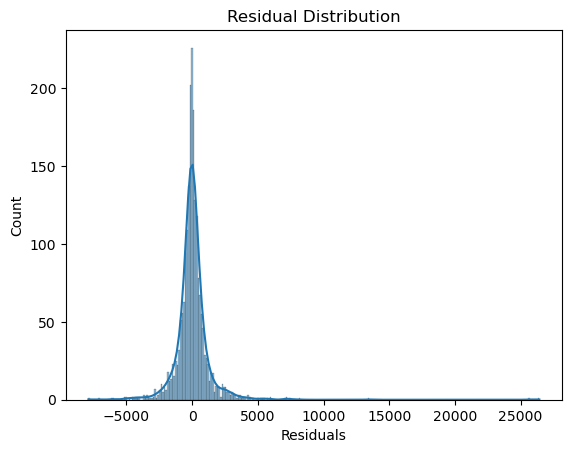

In [123]:
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

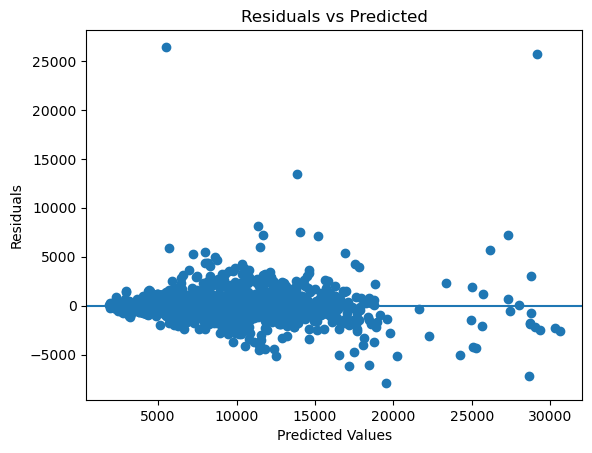

In [124]:
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [125]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print("Upper Limit:", upper_limit)
print("Max Value:", y_train.max())

Upper Limit: 10.715418938945138
Max Value: 11.283675809286734


**No strong outliers**

<h3>Permutation Importance</h3>

How much model performance drops when we shuffle a feature.

In [126]:
from sklearn.inspection import permutation_importance
# Run permutation importance
result = permutation_importance(
    best_hgb,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Get feature names
feature_names = x_test.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)


importance_df.head(15)

,Feature,Importance
10,Duration_total_mins,0.730522
0,Airline,0.411403
6,Journey_Month,0.173782
4,Additional_Info,0.109551
5,Journey_Day,0.095158
9,Arrival_Total_Minutes,0.045536
3,Total_Stops,0.043455
8,Dep_Total_Minutes,0.042163
7,Journey_Weekday,0.025395
1,Source,0.023806


- **Top three features influencing model are Duration_total_mi, Airline,  Journey_Mon**
- **Flight duration heavily influences ticket price,longer flight -> higher price**
- **Airline strongly affects pricing**
- **Peak seasons increase prices**

<h4>Challenges Faced and Technique used</h4>

1. Skewed Target variable:
    * Larger residual spread for high prices
    * Can Increase RMSE
    * Potential heteroscedasticity
* Technique used :
    * Log transform to Target variable 
    * Evaluated overfitting gap and CV stability.
2. Mild overfitting :
    * Mild Overfitting in Tree-Based Models
    * Gap 0.04 to 0.07
* Technique used :
    * Hyperparameter tuning
    * Reduced model complexity by
       * Controlled tree depth ,Tuned learning rate
    * 5 fold  Cross validation
3. Dataset with no numerical type :
    * Large number of  object datatypes
    * Challenges the feature engineering
* Technique used :
    * Heavy Feature Engineering
4. Mild heteroscedasticity :
    * Numerical features had very different ranges
    * affects the model performance
* Technique Used :
    * Performed residual histogram analysis
    * Plotted residuals vs predicted values

<h4>Completed Task 4:-Create a report which should include challenges you faced on data and what technique used with proper reason.</h4>